In [2]:
import pandas as pd
df = pd.read_csv("../DATA/apple_stock.csv")
print(df.shape)
df.head()

(10468, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB


In [4]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [6]:
df = df.drop(columns=["Date","Adj Close"])
df.head()

,Open,High,Low,Close,Volume
0,0.128348,0.128906,0.128348,0.128348,469033600
1,0.122210,0.122210,0.121652,0.121652,175884800
2,0.113281,0.113281,0.112723,0.112723,105728000
3,0.115513,0.116071,0.115513,0.115513,86441600
4,0.118862,0.119420,0.118862,0.118862,73449600


In [9]:
X = df.drop(columns=["Close"])
y = df["Close"]
print(X.head())
print(y.head())

       Open      High       Low     Volume
0  0.128348  0.128906  0.128348  469033600
1  0.122210  0.122210  0.121652  175884800
2  0.113281  0.113281  0.112723  105728000
3  0.115513  0.116071  0.115513   86441600
4  0.118862  0.119420  0.118862   73449600
0    0.128348
1    0.121652
2    0.112723
3    0.115513
4    0.118862
Name: Close, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8374, 4)
(2094, 4)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

gb = GradientBoostingRegressor(
    random_state=42
)

ensemble = VotingRegressor(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("gb", gb)
    ]
)

In [13]:
models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "Voting Regressor": ensemble
}

results = []

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

In [14]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.066226,0.241873,0.999937
1,Random Forest,0.098154,0.336624,0.999879
2,Gradient Boosting,0.151335,0.399454,0.999829
3,Voting Regressor,0.095223,0.298256,0.999905


In [15]:
import pickle

with open("../MODELS/stock_ensemble_model.pkl", "wb") as file:
    pickle.dump(ensemble, file)

print("Model Saved Successfully!")

Model Saved Successfully!


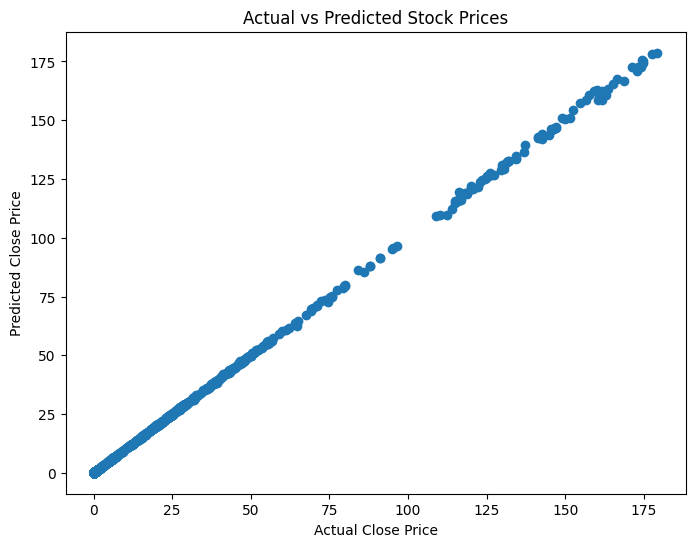

In [16]:
import matplotlib.pyplot as plt

predictions = ensemble.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")

plt.title("Actual vs Predicted Stock Prices")

plt.savefig("../OUTPUTS/actual_vs_predicted.png")

plt.show()

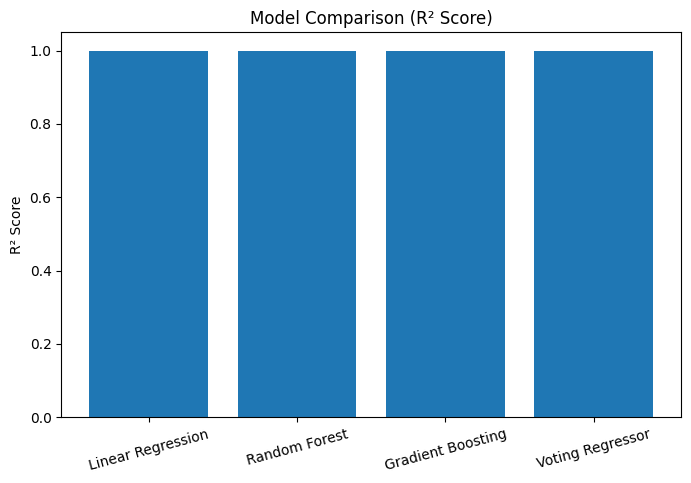

In [17]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("Model Comparison (R² Score)")

plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.savefig("../OUTPUTS/model_comparison.png")

plt.show()

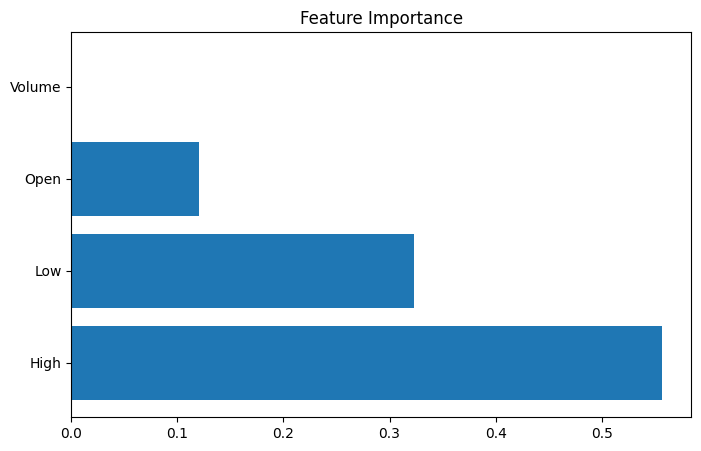

In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.savefig("../OUTPUTS/feature_importance.png")

plt.show()